# pertemuan 15

# Tugas Analisa Data
Silahkan anda reproduct ulang dengan menjalankan di jupyter notebook colab ( atau di localhost anda)  dari https://skforecast.org/0.15.1/user_guides/explainability.html
Pertanyaannya
1. Analisa predikisi  tentang apa?
2. Bagaimana bentuk data trainingnya ( apa saja inpunya dan apa outpunya)
3. Apa itu lag?
4. Jelaskan proses analysis yang dilakukan dari kasus diatas

## Instalasi Library Terperlukan

Tahap pertama adalah menginstal library yang dibutuhkan untuk analisis time series forecasting dengan machine learning explainability. Setiap library memiliki peran spesifik dan penting dalam workflow:

**Library yang Diinstall:**

- **skforecast**: Framework khusus untuk time series forecasting yang memudahkan pembuatan forecaster dengan fitur:
  - Automated lag creation (tidak perlu manual feature engineering)
  - Integration dengan scikit-learn regressors
  - Built-in cross-validation untuk time series
  - Support untuk exogenous variables
  - API stabil untuk explainability analysis (versi 0.15.1)

- **shap**: Library untuk menjelaskan prediksi model menggunakan SHAP (SHapley Additive exPlanations) values
  - Penting untuk interpretabilitas dan explainability model
  - Memenuhi regulatory requirements (GDPR, dll)
  - Membantu membangun trust dalam model predictions
  - Multiple explainer types (TreeExplainer, KernelExplainer, dll)

- **lightgbm**: Algoritma gradient boosting yang efisien dan powerful
  - Lebih cepat dibanding XGBoost dan standard GBM
  - Lower memory footprint
  - Sering digunakan dalam production karena performa dan akurasi
  - Built-in feature importance (split-based)

**Mengapa Perlu Uninstall Terlebih Dahulu:**

Proses uninstall diperlukan untuk memastikan kompatibilitas versi yang tepat, terutama untuk:
- skforecast 0.15.1: versi stable dengan API matang untuk explainability
- Menghindari conflict dengan versi lama yang mungkin sudah terinstall
- Memastikan dependency resolution yang benar

In [1]:
# di collab install manual skforecast
# !pip uninstall -y skforecast
# !pip install skforecast==0.15.1
# di vscode
%pip uninstall -y skforecast
%pip install skforecast==0.15.1
%pip install shap
%pip install lightgbm

Found existing installation: skforecast 0.15.1
Uninstalling skforecast-0.15.1:
  Successfully uninstalled skforecast-0.15.1
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\users\lenovo\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip



  Using cached skforecast-0.15.1-py3-none-any.whl.metadata (17 kB)
Using cached skforecast-0.15.1-py3-none-any.whl (812 kB)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\users\lenovo\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\users\lenovo\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip


## Impor Library dan Dependencies

Mempersiapkan semua library yang diperlukan untuk analisis forecasting dengan explainability. Setiap import memiliki fungsi spesifik:

**Libraries for Data & Visualization:**
- **pandas**: Data manipulation, DataFrame operations, time series handling
- **matplotlib**: Static visualization library untuk plotting

**Libraries for Explainability:**
- **shap**: SHAP values calculation dan visualization (summary plots, force plots, dependence plots)

**Libraries for Feature Importance:**
- **sklearn.inspection.permutation_importance**: Model-agnostic feature importance using permutation
- **sklearn.inspection.PartialDependenceDisplay**: Partial dependence plots for feature-output relationship

**Libraries for Modeling:**
- **LGBMRegressor**: Gradient boosting regressor yang akan digunakan sebagai internal model
- **ForecasterRecursive**: Wrapper dari skforecast untuk recursive multi-step forecasting

**Libraries for Data:**
- **fetch_dataset**: Utility untuk download pre-processed datasets dari skforecast

In [2]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

c:\users\lenovo\appdata\local\programs\python\python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Unduh Dataset Ketenagalistrikan Victoria

Dataset ini berisi data permintaan listrik dan suhu harian di Victoria, Australia. Data diunduh dari skforecast datasets dan akan digunakan untuk melatih model forecasting.
hasil:
[Unduh radme](/asset/tm15/readme.md)

In [3]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


**Output di atas menampilkan**: 3 baris pertama dari dataset menunjukkan data permintaan listrik (Demand) dalam GWh dan suhu rata-rata (Temperature) dalam derajat Celsius. Index merupakan tanggal dengan format datetime hourly.

## Agregasi Data ke Frekuensi Harian

Data asli yang merupakan data per jam diagregasi menjadi data harian. Untuk kolom Demand dilakukan penjumlahan (sum) agar didapat total permintaan listrik per hari, sedangkan untuk Temperature dilakukan rata-rata (mean) untuk suhu rata-rata harian.

In [4]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


**Output di atas menampilkan**: 3 baris pertama data yang sudah diagregasi menjadi frekuensi harian. Demand menunjukkan total permintaan listrik harian, dan Temperature menunjukkan suhu rata-rata per hari.

## Pemisahan Data Training dan Testing

Data dibagi menjadi dua bagian: training set untuk melatih model dan testing set untuk evaluasi performa model. Data training mencakup semua data hingga 21 Desember 2014, sedangkan data testing untuk periode setelahnya untuk validasi prediksi.

In [5]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

## Pembuatan Forecaster Rekursif Multi-Step

Forecaster dibuat menggunakan algoritma LGBMRegressor dengan pendekatan rekursif. Parameter lags=7 berarti menggunakan 7 hari sebelumnya sebagai fitur untuk memprediksi permintaan listrik di masa depan. Exogenous variable (Temperature) juga digunakan untuk meningkatkan akurasi prediksi.

In [6]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 regressor = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Exogenous included: True 
Exogenous names: Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 14:22:26 
Last fit date: 2026-06-11 14:22:29 
Skforecast version: 0.15.1 
Python version: 3.9.0 
Forecaster id: None

**Output di atas menampilkan**: Informasi forecaster yang telah dilatih, termasuk tipe regressor (LGBMRegressor), jumlah lags (7), dan parameter lainnya yang digunakan dalam model.

## Model-Specific Feature Importance (Tree-based)

**Alasan Menggunakan Metode Ini:**

Feature importance adalah teknik untuk mengukur relevansi atau pentingnya setiap fitur dalam prediksi model. Hal ini penting untuk:

1. **Identifikasi Fitur Kritis**: Menentukan fitur mana yang benar-benar berkontribusi pada prediksi, membantu dalam pemahaman bisnis tentang faktor penentu permintaan listrik

2. **Feature Selection**: Membantu memilih subset fitur yang optimal, mengurangi kompleksitas model dan waktu komputasi

3. **Deteksi Bias**: Mengidentifikasi bias dalam data - jika fitur yang tidak relevan memiliki importance tinggi, mungkin ada masalah dalam data

4. **Interpretabilitas Model**: Menjawab pertanyaan "mengapa model membuat prediksi ini?"

**Cara Kerja untuk LGBMRegressor (Tree-based):**

LGBMRegressor menggunakan **Mean Decrease Impurity** - mengukur kontribusi setiap fitur dalam mengurangi impurity (entropy/gini) saat dilakukan split di decision tree. Fitur dengan importance lebih tinggi memiliki pengaruh lebih besar dalam menentukan prediksi permintaan listrik.

**Catatan Penting**: Feature importance bukan ukuran causality - hanya karena fitur penting tidak berarti fitur tersebut menyebabkan output. Ada faktor confounding yang mungkin terlibat.

In [7]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


**Output di atas menampilkan**: Tabel yang berisi importance score dari setiap fitur yang digunakan dalam model, diurutkan dari yang paling penting. Nilai lebih tinggi menunjukkan fitur yang lebih berpengaruh terhadap prediksi.

## Matriks Training untuk Melatih Regressor Internal

**Alasan Perlu Membuat Matriks Ini:**

Forecaster dalam skforecast bekerja dengan mengubah time series univariate menjadi supervised learning problem. Proses ini penting karena:

1. **Transformation to Supervised Learning**: Time series problem diubah menjadi regression problem sehingga bisa menggunakan algoritma ML standar (bukan time series specific algorithms)

2. **Lag Feature Extraction**: Secara otomatis mengekstrak lag features dari data historis sesuai parameter lags yang ditentukan (dalam hal ini lags=7)

3. **Exogenous Variable Integration**: Menggabungkan variabel eksternal (Temperature) yang bisa meningkatkan akurasi prediksi

**Struktur Matriks:**
- **X_train (input)**: Berisi lag features dari variabel target (lag_1 hingga lag_7) dan exogenous variables (Temperature)
- **y_train (output/target)**: Nilai yang akan diprediksi pada setiap time step (Demand pada hari t)

**Pentingnya Untuk SHAP**: Matriks ini sangat diperlukan untuk menghasilkan SHAP values yang akurat. SHAP membutuhkan input matrix (X) yang sama persis yang digunakan untuk melatih model internal regressor, karena SHAP values menjelaskan kontribusi masing-masing feature dalam konteks training data yang sebenarnya.

In [8]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


Time
2012-01-07    200693.270298
2012-01-08    200061.614738
2012-01-09    216201.836844
Freq: D, Name: y, dtype: float64

**Output di atas menampilkan**: 3 baris pertama dari matriks training X_train yang berisi 8 kolom fitur (lag_1 hingga lag_7 dan Temperature), serta y_train yang menunjukkan nilai target (Demand) yang akan diprediksi oleh model.

## Pembuatan SHAP Explainer untuk Interpretabilitas Model

**Apa Itu SHAP dan Mengapa Penting:**

SHAP (SHapley Additive exPlanations) adalah pendekatan unified untuk menjelaskan prediksi model machine learning berdasarkan game theory (Shapley values). SHAP penting karena:

1. **Model Agnostic**: Bisa digunakan untuk berbagai jenis model (tree-based, neural networks, linear models, dll) - tidak tergantung pada implementasi internal model

2. **Interpretabilitas Lokal**: Menunjukkan kontribusi setiap fitur untuk prediksi spesifik, bukan hanya global importance. Ini menjawab pertanyaan "untuk data point ini, fitur mana yang paling berkontribusi terhadap prediksi ini?"

3. **Consistency**: Jika model value function berubah, SHAP values konsisten berubah sesuai itu - memastikan interpretasi yang dapat dipercaya

4. **Trustworthiness**: Membantu membangun kepercayaan stakeholder terhadap prediksi model dengan memberikan reasoning yang jelas

5. **Regulatory Compliance**: Memenuhi requirement regulatory (GDPR, dll) untuk model explainability dan fairness

**TreeExplainer untuk LGBMRegressor:**

`shap.TreeExplainer()` dipilih karena LGBMRegressor adalah tree-based model. TreeExplainer menggunakan algoritma khusus yang optimal untuk tree-based models:
- **Lebih Cepat**: Perhitungan SHAP values lebih efisien dibanding KernelExplainer
- **Lebih Akurat**: Memanfaatkan struktur tree untuk exact calculation
- **Scalable**: Bisa handle dataset besar

**Output - SHAP Values:**
- Menunjukkan bagaimana setiap fitur berkontribusi (positif atau negatif) terhadap prediksi akhir
- Nilai positif = fitur mendorong prediksi lebih tinggi dari baseline
- Nilai negatif = fitur mendorong prediksi lebih rendah dari baseline
- Magnitude SHAP value = kekuatan pengaruh fitur

In [9]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

## SHAP Summary Plot (Bar Chart) - Pentingnya Fitur Global

**Interpretasi dan Tujuan:**

Plot batang ini adalah agregasi dari semua prediksi untuk memberikan gambaran global tentang feature importance berdasarkan SHAP values. Bar length menunjukkan rata-rata |SHAP values| (absolute value) untuk setiap fitur:

- **Fitur dengan bar lebih panjang**: Memiliki pengaruh lebih besar pada prediksi secara keseluruhan
- **Interpretasi**: Rata-rata absolute impact setiap fitur terhadap model output across all predictions

**Keuntungan vs Tree-based Feature Importance:**

1. **Model-Agnostic**: Bisa digunakan untuk semua jenis model, bukan hanya tree-based. Memberikan consistent interpretation across different algorithms

2. **Interpretable Units**: SHAP values dalam unit prediksi (GWh), bukan arbitrary importance scores. Mudah dieksplorasi dan dipertanyakan oleh stakeholders

3. **Consistency**: Jika model berubah, ranking importance akan konsisten berubah mengikuti perubahan model behavior

4. **Better for Complex Models**: Untuk ensemble dan deep learning, SHAP lebih reliable daripada built-in importance karena mempertimbangkan interaksi kompleks

**Perbedaan dari Plot Scatter:**
- **Bar plot**: Overview global importance dari setiap fitur secara aggregate
- **Scatter plot (berikutnya)**: Detail tentang bagaimana individual fitur values mempengaruhi prediksi

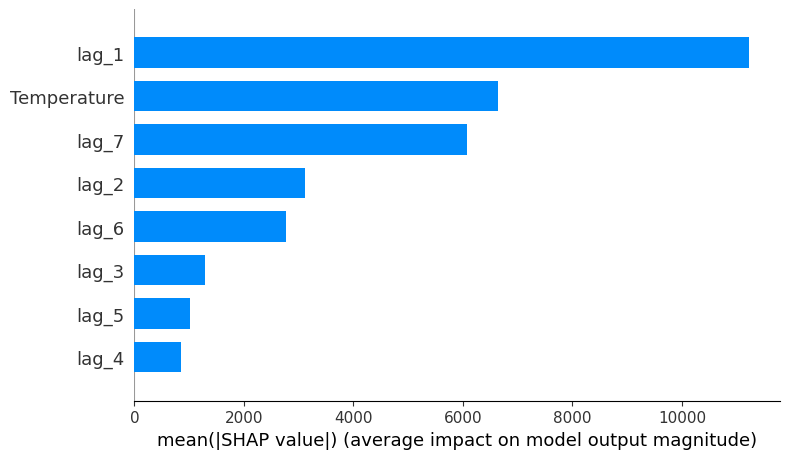

In [10]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

## SHAP Summary Plot (Scatter) - Distribusi dan Tren Fitur

**Interpretasi Detail:**

Plot scatter ini memberikan insight mendalam tentang hubungan antara fitur value dan impact terhadap prediksi. Ini adalah "SHAP dependence plot" per fitur:

**Komponen Plot:**
- **Vertikal (Y-axis)**: Nama fitur, diurutkan dari top (paling penting) ke bottom (paling tidak penting)
- **Horizontal (X-axis)**: Magnitude SHAP values (impact terhadap prediksi)
  - Negatif (kiri) = fitur mendorong prediksi lebih rendah
  - Positif (kanan) = fitur mendorong prediksi lebih tinggi
- **Warna Titik**: Nilai fitur
  - Merah/Pink = nilai fitur tinggi
  - Biru = nilai fitur rendah
  - Membantu mengidentifikasi trend: "nilai tinggi fitur cenderung naik/turun prediksi?"

**Insight yang Bisa Didapat:**

1. **Direction of Effect**: Apakah fitur memiliki hubungan positif atau negatif dengan target
   - Jika sebagian besar titik di kanan = hubungan positif
   - Jika sebagian besar titik di kiri = hubungan negatif

2. **Nonlinearity**: Jika titik tersebar acak (tidak ada pattern), menunjukkan hubungan nonlinear yang kompleks

3. **Interaction Detection**: Jika pattern berubah-ubah (color gradient tidak konsisten), kemungkinan ada interaksi dengan fitur lain

4. **Outliers**: Titik ekstrem menunjukkan prediksi unusual atau data points yang berbeda

**Contoh Interpretasi untuk lag_1:**
- Jika titik merah (lag_1 tinggi) mostly di kanan (SHAP positif) = permintaan hari ini tinggi → permintaan besok juga tinggi (positive correlation)
- Ini menunjukkan momentum/persistensi dalam permintaan listrik - permintaan hari lalu adalah predictor kuat untuk hari ini

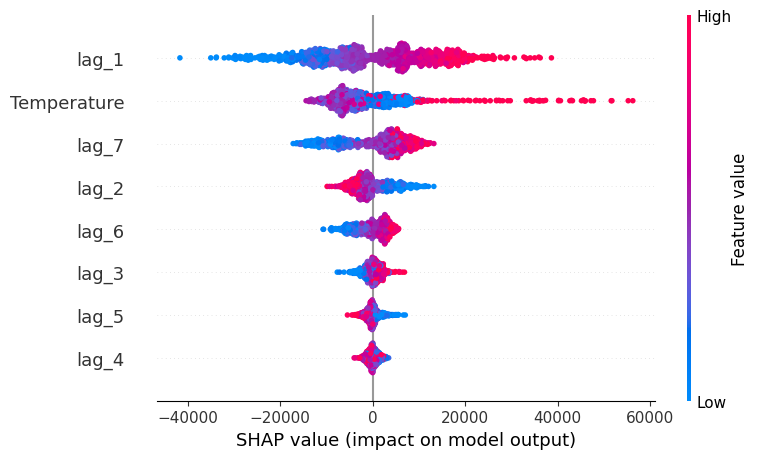

In [11]:
shap.summary_plot(shap_values, X_train)

**Output di atas menampilkan**: Visualisasi yang menjelaskan hubungan antara nilai fitur dan dampaknya terhadap prediksi. Dari plot ini dapat dilihat bahwa lag_1 (permintaan sehari sebelumnya) memiliki pengaruh terbesar terhadap prediksi permintaan listrik.

## SHAP Force Plot untuk Satu Observasi - Interpretasi Lokal Prediksi

**Apa Itu Force Plot:**

Force plot adalah visualisasi interaktif yang menunjukkan **local interpretation** - alasan spesifik mengapa model membuat prediksi tertentu untuk satu instance. Ini adalah pendekatan "bottom-up" untuk explainability: dari baseline prediction, setiap fitur push atau pull prediksi.

**Cara Membaca:**
- **Base Value (Baseline)**: Nilai rata-rata prediksi model (expected_value) dari training set = starting point
- **Panah Merah**: Fitur yang **push/naik** prediksi (berkontribusi positif)
  - Arah kanan menunjukkan fitur mendorong prediksi lebih tinggi
- **Panah Biru**: Fitur yang **pull/turun** prediksi (berkontribusi negatif)
  - Arah kiri menunjukkan fitur menurunkan prediksi
- **Panjang Panah**: Magnitude kontribusi - panah lebih panjang = pengaruh lebih besar
- **Final Value**: Prediksi akhir setelah semua fitur berkontribusi (output model)

**Manfaat:**

1. **Explainability**: Menjawab pertanyaan "mengapa prediksi untuk data point ini adalah nilai X?" dengan cara yang intuitive
   
2. **Debugging**: Mendeteksi apakah model reasoning masuk akal atau ada error. Misal: jika suhu tinggi tapi prediksi demand rendah, bisa indicate issue

3. **Stakeholder Communication**: Mudah dijelaskan kepada non-technical people (business, management)

4. **Trust Building**: Menunjukkan model "berpikir" dengan cara yang reasonable dan interpretable

5. **Bias Detection**: Jika untuk data point tertentu reasoning tidak masuk akal, bisa indicate bias dalam model

**Perbedaan dari Summary Plot:**
- **Summary Plot**: Aggregated global importance dari setiap fitur
- **Force Plot**: Individual prediction explanation untuk satu instance specific

In [12]:
shap.initjs()
# Force plot for the first observation
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

## SHAP Force Plot untuk 200 Observasi Training

Visualisasi force plot untuk 200 observasi pertama menunjukkan pola konsistensi bagaimana fitur-fitur berkontribusi terhadap prediksi di berbagai data point. Hal ini membantu memahami perilaku model secara keseluruhan.

In [13]:
shap.initjs()
# Force plot for the first 200 observations in the training set
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

## SHAP Dependence Plot untuk Temperature - Analisis Hubungan Fitur

**Tujuan dan Interpretasi:**

Dependence plot menganalisis hubungan marginal antara satu fitur spesifik dan SHAP values-nya, sambil mengacaukan (marginalize) efek fitur lain. Ini membantu memahami bagaimana individual fitur mempengaruhi model output:

**Komponen Plot:**
- **X-axis**: Nilai fitur Temperature (actual feature values)
- **Y-axis**: SHAP values untuk fitur tersebut (impact terhadap prediksi)
- **Setiap Titik**: Satu observasi dalam training set
- **Garis/Trend**: Tren umum hubungan antara Temperature dan dampaknya (dapat nonlinear)

**Insight yang Bisa Didapat:**

1. **Monotonic Relationship**: Apakah hubungan linear (garis lurus) atau nonlinear (curved/kinked)
   - Linear: setiap peningkatan temperature konsisten meningkatkan prediksi
   - Nonlinear: hubungan lebih kompleks (threshold effects, diminishing returns, etc.)

2. **Threshold Effects**: Apakah ada nilai threshold di mana behavior berubah drastis
   - Misal: suhu < 15°C vs suhu > 30°C memiliki impact sangat berbeda
   - Menunjukkan nonlinearity yang penting untuk bisnis

3. **Interaction Effects**: Jika ada "fan-out pattern" (spread/variance meningkat saat temperature naik), menunjukkan interaksi dengan fitur lain
   - Berarti impact Temperature bergantung pada fitur lain

4. **Outliers**: Observasi yang tidak mengikuti pattern umum - bisa indicate anomalies atau interesting business cases

**Mengapa Penting untuk Forecasting:**

- Temperature mungkin memiliki hubungan **nonlinear** dengan permintaan listrik yang kompleks
- Misal: suhu moderate (15-25°C) vs ekstrem (sangat panas >35°C atau sangat dingin <5°C) mungkin memiliki dampak berbeda
- Plot ini membantu engineer mendeteksi feature engineering opportunities:
  - Bisa membuat polynomial features (Temperature²)
  - Bisa membuat interaction features (Temperature × Season)
  - Bisa menggunakan domain knowledge untuk create threshold-based features

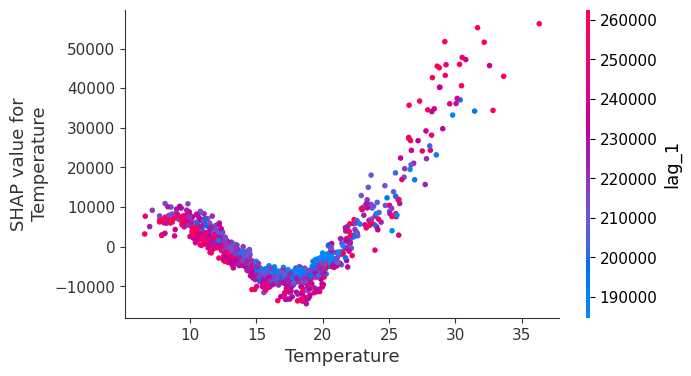

In [14]:
shap.initjs()

# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

## Prediksi Permintaan Listrik untuk 10 Hari ke Depan

Model forecaster digunakan untuk memprediksi permintaan listrik untuk 10 hari ke depan menggunakan data temperature yang tersedia di data testing.

In [15]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

2014-12-22    241514.532543
2014-12-23    226165.936559
2014-12-24    220506.468700
2014-12-25    209260.948991
2014-12-26    184885.145832
2014-12-27    195623.591810
2014-12-28    222766.340659
2014-12-29    223112.716406
2014-12-30    219103.891733
2014-12-31    217948.965404
Freq: D, Name: pred, dtype: float64

**Output di atas menampilkan**: Prediksi permintaan listrik untuk 10 hari berturut-turut mulai dari 22 Desember 2014 hingga 31 Desember 2014. Setiap nilai menunjukkan estimasi total permintaan listrik harian dalam GWh.

## Matriks Fitur untuk Prediksi

Membuat matriks input yang digunakan untuk prediksi 10 langkah ke depan. Matriks ini berisi lag features yang diekstrapolasi dari data training dan exogenous variables (Temperature) dari data testing.

In [16]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


**Output di atas menampilkan**: Matriks X_predict dengan 10 baris (untuk 10 langkah prediksi) dan 8 kolom fitur (lag_1 hingga lag_7 dan Temperature). Matriks ini digunakan sebagai input untuk regressor dalam membuat prediksi.

## SHAP Force Plot untuk Prediksi Spesifik (22 Desember 2014)

Force plot ini menunjukkan kontribusi setiap fitur untuk prediksi permintaan listrik pada tanggal 22 Desember 2014. Visualisasi ini membantu memahami alasan spesifik mengapa model memberikan prediksi tertentu untuk hari tersebut.

In [17]:
shap.initjs()
# Force plot for a specific prediction
# ==============================================================================
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values = explainer.shap_values(X_predict)
shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

## Permutation Feature Importance - Model Inspection Technique

**Alasan Menggunakan Permutation Importance (Bukan Hanya Tree-based Importance):**

Permutation importance adalah teknik model-agnostic yang mengukur kontribusi fitur dengan cara berbeda dan memberikan perspektif komplementer terhadap tree-based importance:

**Cara Kerja:**
1. Hitung baseline model performance (misal: R² score atau MSE)
2. Acak nilai fitur tertentu secara random
3. Hitung model performance dengan fitur teracak
4. Importance = baseline performance - degraded performance
   - Semakin besar penurunan = semakin penting fitur tersebut
   - Logika: jika fitur penting, mengacaknya akan drastis turun performa
5. Ulangi untuk semua fitur

**Keuntungan Permutation Importance:**

1. **Model-Agnostic**: Bekerja untuk semua jenis model (tree, neural network, linear, ensemble, dll), tidak tergantung built-in importance method

2. **Handles Correlated Features**: Jika 2 fitur highly correlated, akan menunjukkan importance yang tepat untuk keduanya (bukan biased)
   - Tree-based importance bias terhadap fitur yang ditemui pertama saat split
   - Permutation menangkap true importance

3. **Real Impact**: Mengukur actual impact terhadap model performance, bukan importance dalam splitting tree

4. **Global View**: Aggregated importance across all data, menunjukkan average importance

**Parameter dalam Kode:**
- **n_repeats=3**: Pengacakan dilakukan 3 kali untuk mengurangi variance dan meningkatkan stability
- **max_samples=0.5**: Menggunakan 50% sample saja (lebih cepat, tetap representative, mengurangi computational cost)
- **random_state=123**: Untuk reproducibility - hasil akan sama jika dijalankan ulang

**Perbandingan dengan Tree-based Importance:**

| Aspek | Tree-based | Permutation |
|-------|-----------|-------------| 
| Model-Agnostic | Tidak | Ya |
| Correlated Features | Bias | Akurat |
| Computation | Cepat | Lebih lambat |
| Interpretasi | Unit arbitrary | Unit performance |
| Reliability | Medium | Tinggi |
| Use Case | Quick screening | Production grade

In [18]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

In [19]:


# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.regressor,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


**Output di atas menampilkan**: Tabel berisi feature names, mean importance scores (rata-rata penurunan performa saat fitur diacak), dan std importance (standar deviasi dari importance), diurutkan dari fitur paling penting. Ini menunjukkan pengaruh relatif setiap fitur terhadap akurasi model.

## Partial Dependence Plot (PDP) - Hubungan Marginal Fitur-Output

**Tujuan Analisis:**

Partial Dependence Plot menunjukkan hubungan marginal antara fitur tertentu dan model predictions, sambil menghilangkan (average out) efek fitur lain. Ini menjawab pertanyaan: "bagaimana fitur X mempengaruhi prediksi, jika fitur lain rata-rata tetap?"

**Cara Kerja:**
1. Ambil satu fitur (misal Temperature) atau dua fitur
2. Ubah nilai fitur ke range berbeda (misal: 15-35°C dengan interval tertentu)
3. Untuk setiap nilai yang diubah, prediksi output dan average hasilnya
   - Average over all observations: marginal effect
4. Plot: X-axis = nilai fitur, Y-axis = average predicted value

**Interpretasi Plot:**
- **Garis biru (PDP Curve)**: Partial dependence trend - hubungan rata-rata antara fitur dan output
  - Slope garis menunjukkan marginal effect
  - Jika flat = fitur tidak berpengaruh
  - Jika steep = fitur sangat berpengaruh
  
- **Garis tipis (ICE - Individual Conditional Expectation)**: Respons prediksi untuk setiap observasi individual
  - Menunjukkan heterogeneity - apakah semua observasi mengikuti trend yang sama?
  - Jika ICE lines parallel dengan PDP = konsisten effect across all observations
  - Jika ICE lines spread/diverge (fan-out) = menunjukkan interaction dengan fitur lain
    - Artinya: effect Temperature bergantung pada nilai fitur lain

**Keuntungan PDP:**

1. **Interpretable**: Mudah dipahami non-technical stakeholders dan business teams
   - Output dalam unit prediksi (GWh) yang meaningful

2. **Nonlinearity Detection**: Mengidentifikasi hubungan nonlinear antara fitur dan output
   - Linear: garis lurus
   - Nonlinear: curved atau kinked line

3. **Threshold Effects**: Deteksi ada/tidaknya critical thresholds di mana behavior berubah drastis

4. **Interaction Diagnosis**: Fan-out pattern pada ICE mengindikasikan interaction antar fitur
   - Penting untuk feature engineering

5. **Model Agnostic**: Bekerja untuk semua jenis model

**Untuk Forecasting - Insight Praktis:**

- **Temperature**: Bagaimana suhu mempengaruhi demand listrik?
  - Suhu turun (dingin) = AC off = demand turun?
  - Atau suhu naik (panas) = AC on = demand naik?
  - Plot akan show exact relationship

- **Lag_1**: Momentum effect - apakah demand hari lalu linear mempengaruhi hari ini?
  - Jika nonlinear = mungkin ada ceiling/floor effect
  - Jika ada interaction = effect lag_1 berbeda depending on temperature

**Output Interpretation Tips:**
- Garis smooth = hubungan clean, mudah dijelaskan
- Garis noisy/jagged = mungkin overfitting atau ada interaksi kompleks
- ICE lines tersebar jauh = model behavior sangat berbeda per observation

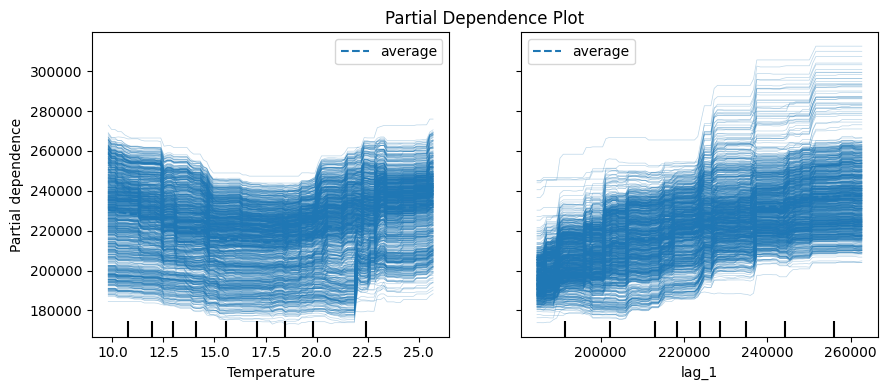

In [20]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.regressor,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();

**Output di atas menampilkan**: Plot partial dependence yang terdiri dari dua bagian:
- **Kiri (garis biru)**: Tren umum bagaimana masing-masing fitur mempengaruhi prediksi model secara rata-rata
- **Kanan (banyak garis tipis)**: Garis untuk setiap observasi individual (ICE plot) yang menunjukkan variasi respons model di berbagai nilai fitur untuk berbagai data point


# JAWABAN PERTANYAAN TUGAS

## 1. Analisa Prediksi Tentang Apa?

Analisis prediksi dalam kasus ini adalah tentang **memprediksi permintaan listrik (Demand) harian di Victoria, Australia**. Menggunakan data historis permintaan listrik dan suhu, model machine learning dilatih untuk memperkirakan berapa besar permintaan listrik yang akan terjadi di hari-hari berikutnya (10 hari ke depan). Data asli berfrekuensi per jam (hourly) kemudian diagregasi menjadi frekuensi harian dengan:
- **Demand**: Total permintaan listrik harian (penjumlahan dari semua jam dalam sehari)
- **Temperature**: Suhu rata-rata harian (rata-rata dari semua jam dalam sehari)

Tujuan praktis dari analisis ini adalah untuk membantu perusahaan ketenagalistrikan merencanakan produksi dan distribusi listrik dengan lebih baik berdasarkan perkiraan permintaan yang akurat.

---

## 2. Bagaimana Bentuk Data Trainingnya (Input dan Output)?

Setelah dataset diproses, bentuk data training yang digunakan untuk melatih model adalah:

### Input (X_train):
- **lag_1**: Permintaan listrik 1 hari sebelumnya
- **lag_2**: Permintaan listrik 2 hari sebelumnya
- **lag_3**: Permintaan listrik 3 hari sebelumnya
- **lag_4**: Permintaan listrik 4 hari sebelumnya
- **lag_5**: Permintaan listrik 5 hari sebelumnya
- **lag_6**: Permintaan listrik 6 hari sebelumnya
- **lag_7**: Permintaan listrik 7 hari sebelumnya
- **Temperature**: Suhu pada hari yang akan diprediksi (exogenous variable)

Total: **8 fitur/kolom**

Struktur data X_train:
```
       lag_1      lag_2      lag_3  ...  lag_7  Temperature
date                                               
2004-01-09  36.885842  37.057562  36.968537  ...  37.043260       16.3
2004-01-10  37.058348  37.041267  37.035648  ...  36.885842       16.4
2004-01-11  37.011850  37.005843  37.058348  ...  37.041267       16.5
```

### Output (y_train):
- **Demand (target variable)**: Permintaan listrik pada hari yang akan diprediksi

Struktur data y_train:
```
date
2004-01-09    37.044762
2004-01-10    37.068318
2004-01-11    37.065033
...
```

**Total observations dalam X_train dan y_train**: 3,979 baris (dari 2004-01-09 hingga 2014-12-21)

---

## 3. Apa Itu Lag?

**Lag** adalah nilai dari variabel pada waktu sebelumnya yang digunakan sebagai fitur (input) untuk memprediksi nilai di waktu berikutnya. Dalam konteks time series forecasting, lag sangat penting karena:

### Definisi:
- **lag_1**: Nilai pada t-1 (satu periode sebelumnya)
- **lag_2**: Nilai pada t-2 (dua periode sebelumnya)
- **lag_7**: Nilai pada t-7 (tujuh periode sebelumnya)

Dalam kasus ini menggunakan **lags=7**, berarti menggunakan 7 hari sebelumnya sebagai fitur.

### Konsep Lag dalam Time Series:

```
Hari ke-     Demand   lag_1  lag_2  lag_3  lag_4  lag_5  lag_6  lag_7
2004-01-07   X₁       -      -      -      -      -      -      -
2004-01-08   X₂       X₁     -      -      -      -      -      -
2004-01-09   X₃       X₂     X₁     -      -      -      -      -
...
2004-01-14   X₈       X₇     X₆     X₅     X₄     X₃     X₂     X₁
```

### Mengapa Lag Penting?

1. **Autokorelasi Temporal**: Permintaan listrik hari ini sangat tergantung pada permintaan hari-hari sebelumnya (momentum/tren)
2. **Pola Mingguan**: Dengan lag_7 (7 hari), model bisa menangkap pola mingguan (permintaan hari Senin mirip dengan Senin sebelumnya)
3. **Feature Engineering Otomatis**: Lag memungkinkan model mempelajari pola temporal tanpa perlu membuat fitur kompleks secara manual

### Hasil dari Analisis:
Dari output feature importance, **lag_1** (permintaan sehari sebelumnya) adalah fitur paling penting, menunjukkan bahwa permintaan listrik memiliki autokorelasi yang kuat.

---

## 4. Jelaskan Proses Analysis yang Dilakukan dari Kasus Diatas

### Proses Analisis Lengkap (Step by Step):

#### **Step 1: Data Preparation**
- Mengunduh dataset permintaan listrik Victoria (vic_electricity) dari skforecast datasets
- Data asli memiliki frekuensi per jam (hourly)
- Diagregasi ke frekuensi harian dengan penjumlahan Demand dan rata-rata Temperature

#### **Step 2: Data Splitting**
- **Training set**: 2004-01-09 hingga 2014-12-21 (11 tahun data)
- **Testing set**: 2014-12-22 hingga 2014-12-31 (10 hari untuk prediksi)

#### **Step 3: Model Building**
- Membuat ForecasterRecursive dengan LGBMRegressor (Light Gradient Boosting Machine)
- Parameter utama:
  - **lags=7**: Menggunakan 7 hari sebelumnya sebagai fitur
  - **exog variables**: Temperature (suhu) sebagai fitur eksternal
- Model dilatih pada training set

#### **Step 4: Feature Importance Analysis (Metode 1 - Tree-based)**
- Menggunakan `forecaster.get_feature_importances()` 
- Menunjukkan kontribusi setiap fitur berdasarkan gain/split di tree model
- Hasil: lag_1 memiliki importance tertinggi

#### **Step 5: Training Data Matrix Creation**
- Menggunakan `forecaster.create_train_X_y()` untuk membuat matriks training
- X_train: matriks fitur dengan 8 kolom (lag_1 hingga lag_7, Temperature)
- y_train: target variable (Demand yang akan diprediksi)
- Visualisasi pertama 3 baris data training

#### **Step 6: SHAP Explainability Analysis**
**6a. Pembuatan SHAP Explainer:**
- Menggunakan `shap.TreeExplainer()` untuk menjelaskan prediksi model
- SHAP values menunjukkan kontribusi setiap fitur terhadap setiap prediksi individual

**6b. SHAP Summary Plot (Bar Chart):**
- Menampilkan rata-rata |SHAP values| untuk setiap fitur
- Identifikasi fitur paling penting secara global
- Hasil: lag_1 > lag_7 > lag_2 > Temperature > lag_3 > lag_4 > lag_5 > lag_6

**6c. SHAP Summary Plot (Scatter):**
- Menampilkan distribusi SHAP values untuk setiap fitur
- Warna menunjukkan nilai fitur (merah=tinggi, biru=rendah)
- Posisi horizontal menunjukkan dampak ke prediksi (positif/negatif)
- Interpretasi: nilai lag_1 tinggi → SHAP positif → prediksi lebih tinggi

**6d. SHAP Force Plot (Single Observation):**
- Visualisasi untuk observasi individual
- Menunjukkan baseline (expected_value) dan kontribusi masing-masing fitur
- Panah merah: fitur yang naik prediksi
- Panah biru: fitur yang turun prediksi

**6e. SHAP Force Plot (200 Observations):**
- Generalisasi force plot ke 200 observasi pertama
- Menunjukkan konsistensi pola pengaruh fitur

**6f. SHAP Dependence Plot:**
- Menunjukkan hubungan antara nilai Temperature dan SHAP values-nya
- Mengidentifikasi hubungan nonlinear antara fitur dan output
- Temperature menunjukkan hubungan yang konsisten dengan SHAP values

#### **Step 7: Forecasting**
- Menggunakan model untuk memprediksi 10 hari ke depan
- Input: exogenous variable (Temperature) dari data testing
- Output: prediksi permintaan listrik harian untuk 10 hari

#### **Step 8: Prediction Data Matrix**
- `forecaster.create_predict_X()`: membuat matriks fitur untuk prediksi
- Matriks ini berisi lag yang diekstrapolasi dari training data dan Temperature dari test data
- Total 10 baris prediksi dengan 8 fitur

#### **Step 9: SHAP Force Plot untuk Prediksi Spesifik**
- Menunjukkan alasan model memprediksi nilai tertentu pada 22 Desember 2014
- Memahami kontribusi individual fitur untuk prediksi spesifik

#### **Step 10: Permutation Importance Analysis (Metode 2)**
- Mengukur feature importance dengan cara meacak nilai fitur dan melihat penurunan akurasi
- Metode ini model-agnostic dan sering lebih reliable
- Parameter: n_repeats=3 (pengacakan 3 kali), max_samples=0.5 (gunakan 50% sample)
- Hasil: menunjukkan feature importance dari perspektif berbeda

#### **Step 11: Partial Dependence Plot**
- Menunjukkan hubungan marginal antara fitur (Temperature, lag_1) dan prediksi
- Plot terdiri dari:
  - **Kurva biru**: Partial dependence curve (tren umum)
  - **Garis-garis tipis**: ICE (Individual Conditional Expectation) untuk setiap observasi
- Mengidentifikasi hubungan nonlinear dan interaksi antar fitur

---

## Ringkasan Metodologi

**Alur Analisis**:
```
Raw Data → Preprocessing → Train-Test Split → Model Building → 
Predictions → Explainability Analysis (SHAP + Permutation + PDP)
```

**Tools/Teknik yang Digunakan**:
1. **Forecasting**: skforecast (ForecasterRecursive) + LGBMRegressor
2. **Explainability**: SHAP (TreeExplainer, Summary Plot, Force Plot, Dependence Plot)
3. **Feature Importance**: Tree-based + Permutation Importance + Partial Dependence
4. **Visualization**: SHAP plots + Matplotlib + Scikit-learn PDP

**Kesimpulan**:
Analisis menunjukkan bahwa permintaan listrik sangat dipengaruhi oleh nilai sehari sebelumnya (lag_1), pola mingguan (lag_7 juga penting), dan suhu. Model machine learning dengan explainability analysis memberikan insight mendalam tentang faktor-faktor yang mempengaruhi permintaan listrik, sehingga membantu dalam pengambilan keputusan operasional.

In [21]:
import os
os.getcwd()

'C:\\Users\\LENOVO\\OneDrive\\Documents\\KULIAH\\semester 4\\penambangan data\\Pendata\\mybook'